In [ ]:
# ============================================================
"""
Script: pinns_L2_vs_sampling.py

Description:
    Train PINNs for different sampling densities and compute
    relative L2 error vs sampling factor.
"""
# ============================================================

#%% ======================== IMPORTS ========================
from datetime import datetime
import sys, os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import glob
import matplotlib.image as mpimg

# Paths
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')
sys.path.insert(0, utilities_dir)

# Custom imports
from analytical_solution_functions import sound_hard_circle_calc, mask_displacement
from pinns_solution_functions import (
    set_seed, generate_points, MLP, init_weights,
    train_adam_with_logs, train_lbfgs_with_logs,
    predict_displacement_pinns
)

# Seed
set_seed(42)

output_dir = "figs_sampling"
os.makedirs(output_dir, exist_ok=True)

In [7]:
r_i = np.pi / 4
l_e = np.pi
side_length = 2 * l_e
n_grid = 501

# Base sampling
n_Omega_P = 10_000
n_Gamma_I = 100
n_Gamma_E = 250

# Training
adam_lr = 1e-2
adam_iters = 1000
lbfgs_iters = 3000

hidden_layers_ = 3
hidden_units_  = 25

# Sampling study
sampling_factors = [0.25, 0.5, 1.0, 2.0, 4.0]
l2_errors = []

# Fixed k
k = 3.0

# Grid
Y, X = np.mgrid[-l_e:l_e:n_grid*1j, -l_e:l_e:n_grid*1j]
R_exact = np.sqrt(X**2 + Y**2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Activation
class Sine(nn.Module):
    def forward(self, x):
        return torch.sin(x)

activation_function_ = Sine()

In [8]:
#%% ======================== ANALYTICAL SOLUTION ========================

u_inc_exact, u_scn_exact, u_exact = sound_hard_circle_calc(k, r_i, X, Y, n_terms=None)
u_inc_exact = mask_displacement(R_exact, r_i, l_e, u_inc_exact)
u_scn_exact = mask_displacement(R_exact, r_i, l_e, u_scn_exact)
u_exact = mask_displacement(R_exact, r_i, l_e, u_exact)

In [9]:
 

#%% ======================== LOOP OVER SAMPLING ========================

for factor in sampling_factors:

    print(f"\nTraining PINN with sampling factor = {factor:.2f}")

    # -------- Scale sampling --------
    n_Omega = int(n_Omega_P * factor)
    n_GammaI = int(n_Gamma_I * factor)
    n_GammaE = int(n_Gamma_E * factor)

    # -------- Training points --------
    x_f, y_f, x_inner, y_inner, x_left, y_left, x_right, y_right, \
    x_bottom, y_bottom, x_top, y_top = generate_points(
        n_Omega, side_length, r_i, n_GammaI, n_GammaE
    )

    # -------- Model --------
    model = MLP(
        input_size=2,
        output_size=2,
        hidden_layers=hidden_layers_,
        hidden_units=hidden_units_,
        activation_function=activation_function_
    ).to(device)

    model.apply(init_weights)

    results = []
    iter_train = 0

    # -------- Adam --------
    iter_train = train_adam_with_logs(
        model,
        x_f, y_f,
        x_inner, y_inner,
        x_left, y_left,
        x_right, y_right,
        x_bottom, y_bottom,
        x_top, y_top,
        k,
        iter_train,
        results,
        adam_lr,
        num_iter=adam_iters,
        save_csv_path=None,
        save_csv_path_no_datetime=None,
        l_e=l_e,
        r_i=r_i,
        n_grid=n_grid,
        X=X,
        Y=Y,
        R_exact=R_exact,
        u_scn_exact=u_scn_exact,
        u_exact=u_exact
    )

    # -------- L-BFGS --------
    train_lbfgs_with_logs(
        model,
        x_f, y_f,
        x_inner, y_inner,
        x_left, y_left,
        x_right, y_right,
        x_bottom, y_bottom,
        x_top, y_top,
        k,
        iter_start=iter_train,
        results=results,
        lbfgs_lr=1.0,
        num_iter=lbfgs_iters,
        save_csv_path=None,
        save_csv_path_no_datetime=None,
        l_e=l_e,
        r_i=r_i,
        n_grid=n_grid,
        X=X,
        Y=Y,
        R_exact=R_exact,
        u_scn_exact=u_scn_exact,
        u_exact=u_exact
    )

    # -------- Prediction --------
    u_sc_amp_pinns, _, _, _ = predict_displacement_pinns(
        model, l_e, r_i, k, n_grid
    )

    # -------- L2 error --------
    u_exact_masked = np.copy(u_scn_exact)
    u_pred_masked  = np.copy(u_sc_amp_pinns)

    u_exact_masked[R_exact < r_i] = 0
    u_pred_masked[R_exact < r_i] = 0

    rel_L2 = np.linalg.norm(u_exact_masked.real - u_pred_masked.real, 2) / \
             np.linalg.norm(u_exact_masked.real, 2)

    print(f"factor = {factor:.2f}, L2 error = {rel_L2:.3e}")

    l2_errors.append(rel_L2)

    # ------------------ Error map ------------------
    error_map = np.abs(u_exact_masked.real - u_pred_masked.real)

    u_pinns_plot = np.ma.masked_where(R_exact < r_i, u_sc_amp_pinns)
    u_exact_plot = np.ma.masked_where(R_exact < r_i, u_scn_exact.real)
    error_plot   = np.ma.masked_where(R_exact < r_i, error_map)

    fig, axs = plt.subplots(1, 3, figsize=(8, 3))

    im0 = axs[0].imshow(u_pinns_plot, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='twilight_shifted')
    axs[0].set_title(f'PINNs (f={factor:.2f})', fontsize=8)
    plt.colorbar(im0, ax=axs[0], shrink=0.6)

    im1 = axs[1].imshow(u_exact_plot, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='twilight_shifted')
    axs[1].set_title('Exact', fontsize=8)
    plt.colorbar(im1, ax=axs[1], shrink=0.6)

    im2 = axs[2].imshow(error_plot, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='magma')
    axs[2].set_title(f'Error - L2={rel_L2:.2e}', fontsize=8)
    plt.colorbar(im2, ax=axs[2], shrink=0.6)

    plt.tight_layout()

    filename = os.path.join(output_dir, f"pinns_factor_{factor:.2f}.png")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig)




Training PINN with sampling factor = 0.25
factor = 0.25, L2 error = 9.271e-02

Training PINN with sampling factor = 0.50
factor = 0.50, L2 error = 7.310e-02

Training PINN with sampling factor = 1.00
factor = 1.00, L2 error = 7.280e-02

Training PINN with sampling factor = 2.00
factor = 2.00, L2 error = 7.484e-02

Training PINN with sampling factor = 4.00
factor = 4.00, L2 error = 7.414e-02


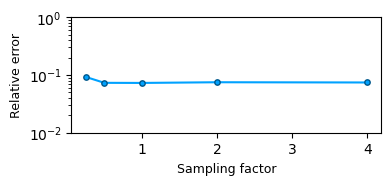

In [16]:
#%% ======================== ERROR CURVE ========================

plt.figure(figsize=(4, 1.5))
plt.plot(sampling_factors, l2_errors, color="#00a2ff", zorder=1)
plt.scatter(sampling_factors, l2_errors, s=15, color="#00a2ff",
               edgecolor="#00578a", zorder=2)
plt.xlabel("Sampling factor", fontsize=9)
plt.ylabel("Relative error", fontsize=9)
plt.yscale('log')
plt.ylim(bottom=1e-2, top=1e-0)

os.makedirs("figures", exist_ok=True)
date_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

plt.savefig(f"figures/pinns_error_vs_sampling_{date_str}.png", dpi=300)
plt.show()

#%% ======================== SAVE DATA ========================

os.makedirs("data", exist_ok=True)
np.save(f"data/pinns_L2_errors_sampling_{date_str}.npy", np.array(l2_errors))

 